### Run ECA for drought-epidemic events

In [1]:
# set up
import pandas as pd
import os
import numpy as np

path = '/gpfs/work4/0/FWC2/Spatial_dependence/Disease_outbreak/global'

In [2]:
# Load EM-DAT
df_emdat = pd.read_csv(os.path.join(path,"data","public_emdat_custom_request_admin1.csv"))

# Clean EM-DAT by deleting those without a start date

df_emdat["Start date"] = pd.to_datetime(
    df_emdat[["Start Year", "Start Month"]].rename(
        columns={"Start Year": "year", "Start Month": "month"}
    ).assign(day=1),
    utc=True,
)

df_emdat.dropna(subset="Start date", inplace=True)

In [3]:
# Filter for hazards
natural_all = True
waterborne = True
hazard_grouping = False

# Set up time period, epidemic fileter, count_threshold
time_filter = (df_emdat["Start Year"] >= 1950) & (df_emdat["Start Year"] <= 2024)
count_threshold = 10

# Epidemic filter
if waterborne:
    epi_type = ['Campylobacter','Cholera','Cryptosporidiosis','Cyclosporiasis','Dengue','Giardiasis','Hepatitis A',
                'Legionellosis','Malaria','Salmonellosis','Shigellosis','Typhoid','Vibrio','Yellow Fever']
    # CDC definitions (https://www.cdc.gov/healthy-water-data/about/nationally-notifiable-waterborne-diseases.html)
    # Malaria and Yellow Fever are vector or insectborne but associated with water; Dengue is also classified as water-related disease

    pattern = "|".join(epi_type)
    epidemic_filter = (
        df_emdat["Event Name"]
        .fillna("")
        .str.contains(pattern, case=False, na=False, regex=True)
    )
    disease_type = "waterborne"
else:
    epi_type = "Epidemic"
    epidemic_filter = df_emdat["Disaster Type"] == epi_type
    disease_type = "epidemic"

# Natural hazard fileter
def make_hazard_filter(df, hazard_type):
    if hazard_grouping:
        disaster_type = df.get("Disaster Subgroup", pd.Series("", index=df.index)).fillna("")
    else:
        disaster_type = df.get("Disaster Type", pd.Series("", index=df.index)).fillna("")
    disaster_subtype = df.get("Disaster Subtype", pd.Series("", index=df.index)).fillna("")

    if hazard_type == "Mass movement":
        return (
            disaster_type.str.startswith("Mass movement", na=False)
        )

    return (
        disaster_type.eq(hazard_type)
        | disaster_type.str.contains(hazard_type, case=False, na=False, regex=False)
        | disaster_subtype.str.contains(hazard_type, case=False, na=False, regex=False)
    )

if hazard_grouping:
    hazard_type_all = ['Climatological', 'Geophysical', 'Hydrological', 'Meteorological']
else:
    hazard_type_all = ['Flood', 'Drought', 'Storm', 'Mass movement','Volcanic activity', 'Wildfire', 'Extreme temperature', 'Earthquake']

if natural_all:
    hazard_type_all = ['Flood', 'Drought', 'Storm', 'Mass movement','Volcanic activity', 'Wildfire', 'Extreme temperature', 'Earthquake']
    # hazard_filter = df_emdat["Disaster Subgroup"].isin(hazard_type_all)
    hazard_filter = pd.concat(
        [make_hazard_filter(df_emdat, h) for h in hazard_type_all],
        axis=1
    ).any(axis=1)
    Country_list = np.unique(df_emdat['Country'])
    out_dir = os.path.join(path, 'data', 'eca_binary','multi_hazard', f'{disease_type}', 'Natural Hazard')
    # out_dir = os.path.join(path, 'data', 'eca_binary', f'{disease_type}', 'Natural Hazard_see country number')
    os.makedirs(out_dir, exist_ok=True)
    hazard_type = "Natural Hazard"

    for COUNTRY in Country_list:
        location_filter = df_emdat["Country"] == COUNTRY
        df_hazards = df_emdat.loc[time_filter & hazard_filter & location_filter]
        # df_hazards = df_hazards.loc[~df_hazards["DisNo."].duplicated(keep="first")]
        df_hazards = df_hazards.drop_duplicates(
            subset=["DisNo.", "admin1"],
            keep="first"
        )

        df_epidemics = df_emdat.loc[time_filter & epidemic_filter & location_filter]
        # df_epidemics = df_epidemics.loc[~df_epidemics["DisNo."].duplicated(keep="first")]
        df_epidemics = df_epidemics.drop_duplicates(
            subset=["DisNo.", "admin1"],
            keep="first"
        )
        # Count the number of hazards and epidemics for each country
        hazard_count = len(df_hazards)
        epidemic_count = len(df_epidemics)

        if hazard_count>=count_threshold and epidemic_count>=count_threshold: 
        # if hazard_count>0 and epidemic_count>0: 
            # Rename disaster type column to flood or epidemic and make boolean
            df_hazards = df_hazards[["Start date","DisNo.","Disaster Subgroup", "Disaster Type","Associated Types","admin1"]].rename(
                columns={"admin1": "Location"})
            df_hazards[hazard_type] = True
            # df_hazards = df_hazards.dropna() # remove rows where no admin1 information is provided
            df_hazards["Location"] = df_hazards["Location"].fillna(COUNTRY).copy() # if no admin1 data (only available for events after 2000), assign the country name
            df_hazards = df_hazards.sort_values(by="Start date").reset_index(drop=True)    


            df_epidemics = df_epidemics[["Start date","DisNo.","Disaster Type","Associated Types","admin1"]].rename(
                columns={"Disaster Type": 'Epidemic',
                            "admin1": "Location"})
            df_epidemics['Epidemic'] = True
            # df_epidemics = df_epidemics.dropna() # remove rows where no admin1 information is provided
            df_epidemics["Location"] = df_epidemics["Location"].fillna(COUNTRY).copy() # if no admin1 data (only available for events after 2000), assign the country name
            df_epidemics = df_epidemics.sort_values(by="Start date").reset_index(drop=True)
            
            # Save to file
            df_hazards.to_csv(os.path.join(out_dir, "df_eca_{:s}_".format(hazard_type) + COUNTRY + '.csv'), index=False)
            df_epidemics.to_csv(os.path.join(out_dir, "df_eca_{:s}_".format('Epidemic') + COUNTRY + '.csv'), index=False)

else:
    # hazard_type_all = ['Mass movement']
    for hazard_type in hazard_type_all:
        hazard_filter = make_hazard_filter(df_emdat, hazard_type)
        
        Country_list = np.unique(df_emdat['Country'])
        # out_dir = os.path.join(path, 'data', 'eca_binary',f'{disease_type}', 'country', hazard_type)
        out_dir = os.path.join(path, 'data', 'eca_binary',f'{disease_type}', 'country', hazard_type)

        os.makedirs(out_dir, exist_ok=True)     


        for COUNTRY in Country_list:
            location_filter = df_emdat["Country"] == COUNTRY
            df_hazards = df_emdat.loc[time_filter & hazard_filter & location_filter]
            df_hazards = df_hazards.drop_duplicates(
                subset=["DisNo.", "admin1"],
                keep="first"
            )

            df_epidemics = df_emdat.loc[time_filter & epidemic_filter & location_filter]
            df_epidemics = df_epidemics.drop_duplicates(
                subset=["DisNo.", "admin1"],
                keep="first"
            )

            # Count the number of hazards and epidemics for each country
            hazard_count = len(df_hazards)
            epidemic_count = len(df_epidemics)

            if hazard_count>=count_threshold and epidemic_count>=count_threshold: 

        #         rows.append({
        #             "Country": COUNTRY,
        #             hazard_type + "_count": hazard_count,
        #             "Epidemic_count": epidemic_count
        #         })

        # # Build the stats DataFrame once after the loop
        # columns = ["Country", hazard_type + "_count", "Epidemic_count"]
        # df_stats = pd.DataFrame(rows, columns=columns)

        # df_stats.to_csv(os.path.join(path,'data','hazard_epidemic', "df_stats_" + hazard_type + '.csv'), index=False)

                # Rename disaster type column to flood or epidemic and make boolean
                df_hazards = df_hazards[["Start date","DisNo.","Disaster Type","admin1"]].rename(
                    columns={"Disaster Type": hazard_type,
                                "admin1": "Location"})
                df_hazards[hazard_type] = True
                # df_hazards = df_hazards.dropna() # remove rows where no admin1 information is provided
                df_hazards["Location"] = df_hazards["Location"].fillna(COUNTRY).copy() # if no admin1 data (only available for events after 2000), assign the country name
                df_hazards = df_hazards.sort_values(by="Start date").reset_index(drop=True)    


                df_epidemics = df_epidemics[["Start date","DisNo.","Disaster Type","admin1"]].rename(
                    columns={"Disaster Type": 'Epidemic',
                                "admin1": "Location"})
                df_epidemics['Epidemic'] = True
                # df_epidemics = df_epidemics.dropna() # remove rows where no admin1 information is provided
                df_epidemics["Location"] = df_epidemics["Location"].fillna(COUNTRY).copy() # if no admin1 data (only available for events after 2000), assign the country name
                df_epidemics = df_epidemics.sort_values(by="Start date").reset_index(drop=True)
                
                # Save to file
                df_hazards.to_csv(os.path.join(out_dir, "df_eca_{:s}_".format(hazard_type) + COUNTRY + '.csv'), index=False)
                df_epidemics.to_csv(os.path.join(out_dir, "df_eca_{:s}_".format('Epidemic') + COUNTRY + '.csv'), index=False)

In [8]:
hazard_type_all = ['Flood', 'Drought', 'Storm', 'Landslide', 'Volcanic activity', 'Wildfire', 'Extreme temperature', 'Earthquake']
disease_type='waterborne'
df_iso = pd.read_csv(os.path.join(path,'data/global_country_iso.csv'))

from collections import defaultdict
import glob
import pycountry

country_hazards = defaultdict(set)
country_outbreaks = defaultdict(set)
epidemic_files_seen = set()
country_counts = defaultdict(lambda: defaultdict(int))
for hazard in hazard_type_all:

    hazard_folder = os.path.join(path, 'data', 'eca_binary',disease_type, 'country', hazard)

    # Disease outbreak files
    epidemic_files = glob.glob(os.path.join(hazard_folder,'df_eca_Epidemic_*.csv'))

    for f in epidemic_files:
        country = os.path.basename(f).replace(
            'df_eca_Epidemic_', ''
        ).replace('.csv', '')
        # Add country to outbreak set
        country_outbreaks[country].add(f)
        if country not in epidemic_files_seen:
            df = pd.read_csv(f)
            country_counts[country]['Epidemic'] = len(df)
            epidemic_files_seen.add(country)

    # Hazard files
    hazard_files = glob.glob(os.path.join(hazard_folder,f'df_eca_{hazard}_*.csv'))

    for f in hazard_files:

        country = os.path.basename(f).replace(
            f'df_eca_{hazard}_', ''
        ).replace('.csv', '')

        country_hazards[country].add(hazard)
        df = pd.read_csv(f)
        country_counts[country][hazard] = len(df)

# --------------------------------------------------
# Create dataframe
# --------------------------------------------------

countries = sorted(country_counts.keys())

df_country_counts = pd.DataFrame(
    0,
    index=countries,
    columns=['Epidemic'] + hazard_type_all
)

for country in countries:

    for variable, count in country_counts[country].items():
        df_country_counts.loc[country, variable] = count


# # Optional: total number of hazard cases
# df_country_counts['Total_hazard_cases'] = (
#     df_country_counts[hazard_type_all].sum(axis=1)
# )

df_country_counts = df_country_counts.reset_index()
df_country_counts = df_country_counts.rename(columns={'index': 'Country'})
iso_map = df_iso.set_index('Country')['ISO']
df_country_counts['ISO3'] = df_country_counts['Country'].map(iso_map)

df_country_counts = df_country_counts[
    ['Country', 'ISO3', 'Epidemic'] +
    hazard_type_all
]
df_country_counts.to_csv(os.path.join(path,'output/number_hazards_epidemics_per_country.csv'))

In [9]:
df_country_hazards

,Flood,Drought,Storm,Landslide,Volcanic activity,Wildfire,Extreme temperature,Earthquake
Country,,,,,,,,
Afghanistan,1,1,1,1,0,0,1,1
Angola,1,1,0,0,0,0,0,0
Bangladesh,1,1,1,1,0,0,1,1
Benin,1,0,0,0,0,0,0,0
Bolivia (Plurinational State of),1,1,0,1,0,1,0,0
Brazil,1,1,1,1,0,0,1,0
Burundi,1,1,1,0,0,0,0,0
Cambodia,1,1,1,0,0,0,0,0
Cameroon,1,0,0,0,0,0,0,0


In [7]:
country_hazards

defaultdict(set, {})

### Testing single country

In [44]:
COUNTRY = "India"
time_filter = (df_emdat["Start Year"] >= 1950) & (df_emdat["Start Year"] <= 2024)
epidemic_filter = df_emdat["Disaster Type"] == "Epidemic"
count_threshold = 10

location_filter = df_emdat["Country"] == COUNTRY
df_hazards = df_emdat.loc[time_filter & hazard_filter & location_filter]
df_epidemics = df_emdat.loc[time_filter & epidemic_filter & location_filter]

# Count the number of hazards and epidemics for each country
hazard_count = len(df_hazards)
epidemic_count = len(df_epidemics)

# Rename disaster type column to flood or epidemic and make boolean
df_hazards = df_hazards[["Start date", "DisNo.","Disaster Type","admin1"]].rename(
    columns={"Disaster Type": hazard_type,
                "admin1": "Location"})
df_hazards[hazard_type] = True
# df_hazards = df_hazards.dropna() # remove rows where no admin1 information is provided
df_hazards["Location"] = df_hazards["Location"].fillna(COUNTRY).copy() # if no admin1 data (only available for events after 2000), assign the country name

if hazard_count>=count_threshold and epidemic_count>=count_threshold: 
     # Dates
#     df_hazards.set_index("Start date", inplace=True)
#     df_epidemics.set_index("Start date", inplace=True)



    # df_epidemics = df_epidemics[["DisNo.","Disaster Type","admin1"]].rename(
    #     columns={"Disaster Type": "Epidemic",
    #                 "admin1": "Location"})
    # df_epidemics["Epidemic"] = True
    # # df_epidemics = df_epidemics.dropna() # remove rows where no admin1 information is provided
    # df_epidemics["Location"] = df_epidemics["Location"].fillna(COUNTRY).copy() # if no admin1 data (only available for events after 2000), assign the country name

    # # Create new df for ECA
    # new_index = df_hazards.index.append(df_epidemics.index).unique()
    # df_eca = pd.DataFrame(index=new_index, columns=[hazard_type,"Location_" + hazard_type, "Epidemic","Location_epidemic"])
    # df_eca[[hazard_type,"Location_" + hazard_type]] = df_hazards[[hazard_type,"Location"]]
    # df_eca[["Epidemic","Location_epidemic"]] = df_epidemics[["Epidemic","Location"]]
    # df_eca[[hazard_type,"Epidemic"]] = df_eca[[hazard_type,"Epidemic"]].fillna(False)
    # df_eca = df_eca.sort_index()

In [50]:
df_hazards

,DisNo.,Flood,Location
38860,2015-0054-AFG,True,Laghman
38861,2015-0054-AFG,True,Nangarhar
38862,2015-0054-AFG,True,Panjshir
38863,2015-0054-AFG,True,Badakhshan
38864,2015-0054-AFG,True,Bamyan
...,...,...,...
53825,2024-0486-AFG,True,Kunar
53826,2024-0486-AFG,True,Kunar
53827,2024-0486-AFG,True,Kunar
53828,2024-0486-AFG,True,Nuristan


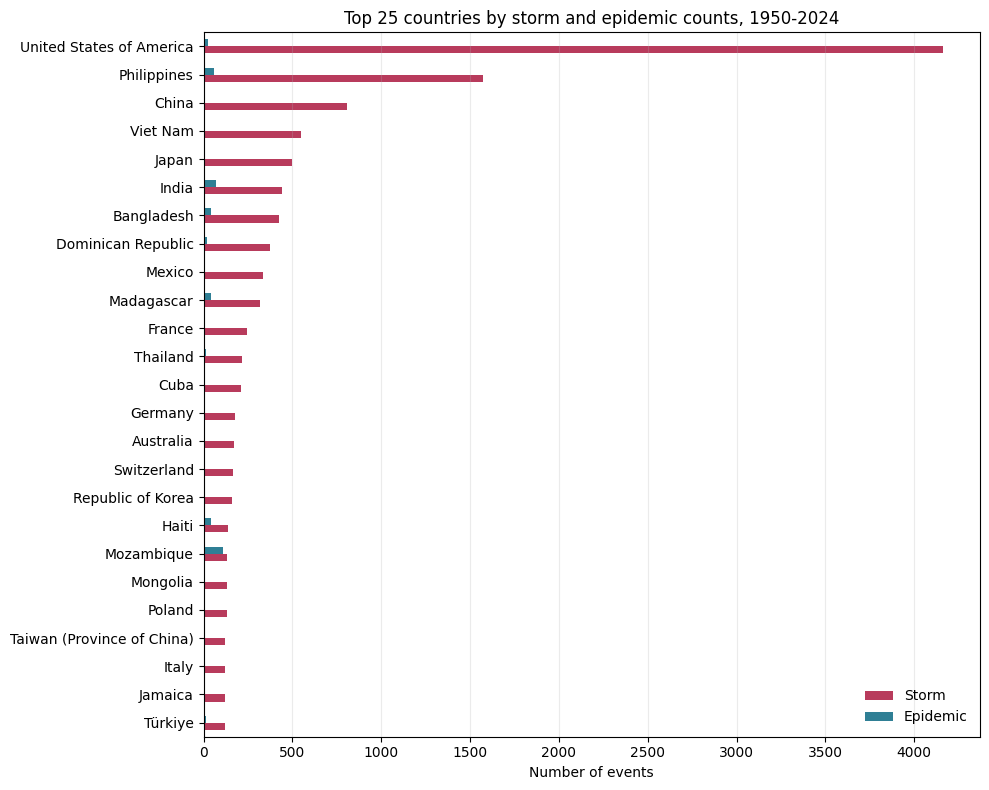

In [27]:
import matplotlib.pyplot as plt

top_n = 25

df_plot = (
    df_stats
    .query(f"{hazard_type}_count > 0")
    .nlargest(top_n, f"{hazard_type}_count")
    .sort_values(f"{hazard_type}_count")
)

ax = df_plot.plot.barh(
    x="Country",
    y=[f"{hazard_type}_count", "Epidemic_count"],
    figsize=(10, 8),
    color=["#b83b5c", "#2f7f95"],
    # color=["#b8643b", "#2f7f95"],
)

ax.set_title(f"Top {top_n} countries by {hazard_type.lower()} and epidemic counts, 1950-2024")
ax.set_xlabel("Number of events")
ax.set_ylabel("")
ax.legend([hazard_type.capitalize(), "Epidemic"], frameon=False)
ax.grid(axis="x", alpha=0.25)

plt.tight_layout()
plt.show()